# Testing different stretch factors to create more robust training for our model

In [1]:
import torch
import pyvista as pv
import numpy as np
from torch_geometric.data import Data
from torch_geometric.transforms import Compose
from sklearn.decomposition import PCA
from transformations import CanonicalAlignment, RobustCanonicalAlignment 
from transformations import LocalDentalStretch, MultiPointDentalStretch, AnatomicalDentalStretch, RandomizedDentalBandStretch


/opt/anaconda3/envs/Dental/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def visualize_transforms(ply_path):
    # 1. Load PLY
    mesh = pv.read(ply_path)
    
    # 2. Find the color array name automatically
    # MeshLab usually exports as 'colors' or 'RGB'
    color_name = None
    for potential_name in ['colors', 'RGB', 'RGBA', 'vertex_colors']:
        if potential_name in mesh.point_data:
            color_name = potential_name
            break
            
    # 3. Convert to Torch Geometric Data
    data = Data(pos=torch.from_numpy(mesh.points).float())
    
    # 4. Define and Run Pipeline
    pipeline = Compose([RobustCanonicalAlignment(), RandomizedDentalBandStretch(), AnatomicalDentalStretch()])
    
    # We apply Alignment only for the "Before" view
    before_data = RobustCanonicalAlignment().forward(Data(pos=data.pos.clone()))
    # Apply full pipeline for the "After" view
    after_data = pipeline(data)
    
    # 5. Helper to convert back to PyVista
    def to_pv(pos_tensor):
        m = mesh.copy()
        m.points = pos_tensor.numpy()
        return m

    before_mesh = to_pv(before_data.pos)
    after_mesh = to_pv(after_data.pos)

    # 6. Plotting
    plotter = pv.Plotter(shape=(1, 2))
    
    # Subplot 1: Before
    plotter.subplot(0, 0)
    plotter.add_text("Aligned Base", font_size=12)
    # Use the detected color_name. If None, it defaults to grey.
    plotter.add_mesh(before_mesh, scalars=color_name, rgb=True if color_name else False)
    
    # Subplot 2: After
    plotter.subplot(0, 1)
    plotter.add_text("Local Stretch", font_size=12)
    plotter.add_mesh(after_mesh, scalars=color_name, rgb=True if color_name else False)
    
    # Add anchor point visualization
    if hasattr(after_data, 'anchor'):
        plotter.add_mesh(pv.Sphere(radius=0.03, center=after_data.anchor.numpy()), color="yellow")

    plotter.link_views()
    plotter.show()

/var/folders/1g/bksky7bd2wb927qzgc2fqjhc0000gn/T/ipykernel_78640/2585262939.py:52: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


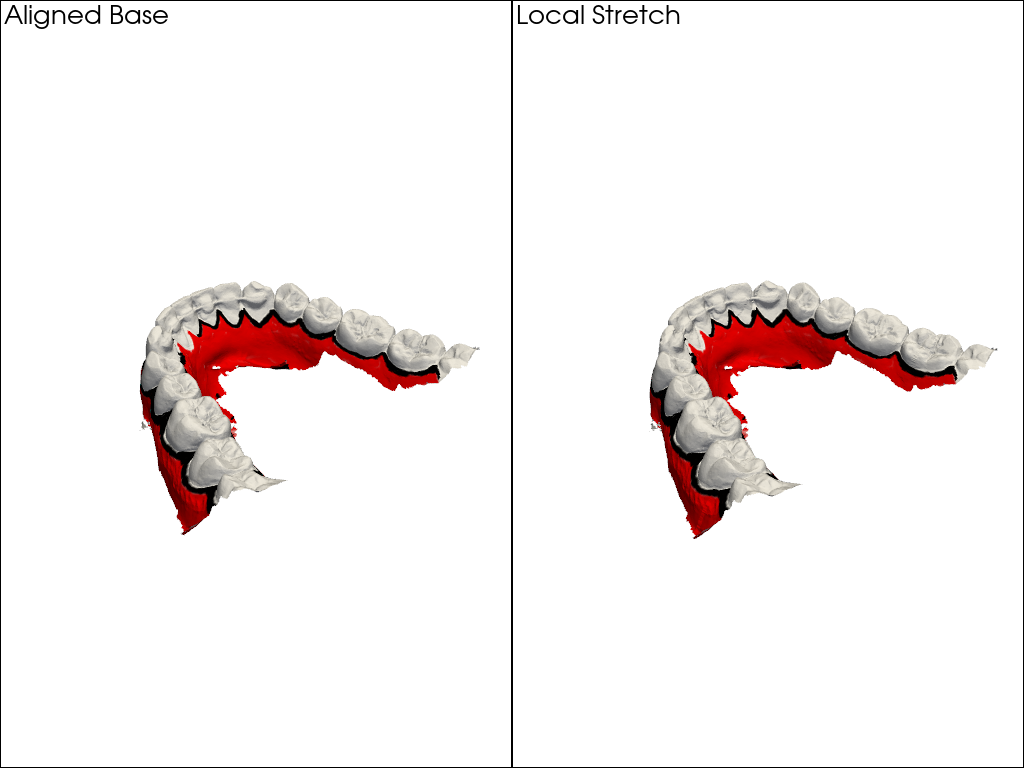

In [50]:
visualize_transforms("../data/1_c.ply")

/var/folders/1g/bksky7bd2wb927qzgc2fqjhc0000gn/T/ipykernel_78640/2585262939.py:52: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


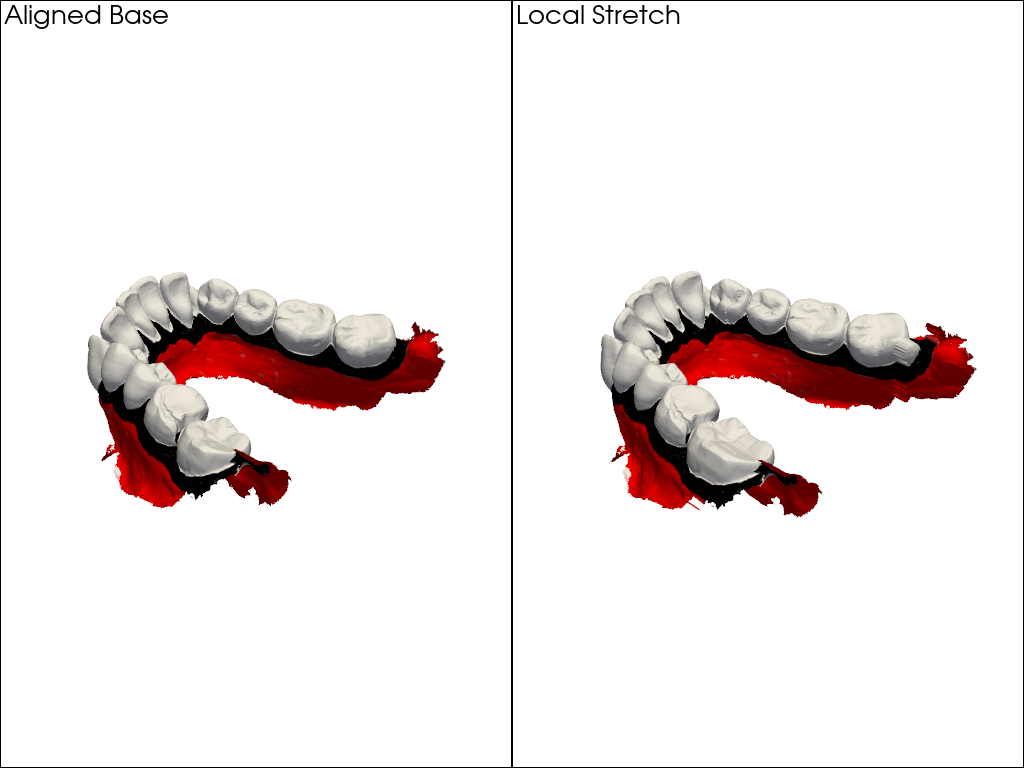

In [17]:
visualize_transforms("../data/ODC3F7X8_lower.ply")